# Integration of the Al1050 data

Every detector frame is integrated azimuthally over a window in q around each selected powder ring,
which gives the array `I[translation, omega, eta, ring]` that the texture tomography is fitted to. The
result is written as a raw memmap (`.bin`) next to a `.json` with all parameters, and is read with
`integration/integrated_data.py` (`IntegratedData`).

The dataset-specific reading (paths, HDF5 layout of the DanMAX files) is in `integration/frame_loader.py`;
this notebook only uses its generic interface.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pyFAI
from integration.frame_loader import (DanMaxDataset, PONI_PATH, dark, INTEGRATED_PATH, OUTPUT_PATH, MASKFILE,
                                      POLARIZATION_FACTOR, read_batch_into_shm, FRAMES, read_frame_batch)
from diffractom import Material
from matplotlib.patches import Rectangle
from concurrent.futures import ProcessPoolExecutor
import json
from datetime import datetime, timezone
import os
import time
from concurrent.futures import ProcessPoolExecutor

dark()


## A few frames
Raw frames at three translations and five rotation angles.

i_trans= 45 (dty= -0.3600)  i_omega=    0 (omega=   0.00)
i_trans= 45 (dty= -0.3600)  i_omega=  750 (omega=  89.97)
i_trans= 45 (dty= -0.3600)  i_omega= 1500 (omega= 179.94)
i_trans= 45 (dty= -0.3600)  i_omega= 2251 (omega= 270.03)
i_trans= 45 (dty= -0.3600)  i_omega= 3001 (omega= 360.00)
i_trans= 90 (dty=  0.0000)  i_omega=    0 (omega=   0.00)
i_trans= 90 (dty=  0.0000)  i_omega=  750 (omega=  89.97)
i_trans= 90 (dty=  0.0000)  i_omega= 1500 (omega= 179.94)
i_trans= 90 (dty=  0.0000)  i_omega= 2251 (omega= 270.03)
i_trans= 90 (dty=  0.0000)  i_omega= 3001 (omega= 360.00)
i_trans=135 (dty=  0.3800)  i_omega=    0 (omega=   0.00)
i_trans=135 (dty=  0.3800)  i_omega=  750 (omega=  89.97)
i_trans=135 (dty=  0.3800)  i_omega= 1500 (omega= 179.94)
i_trans=135 (dty=  0.3800)  i_omega= 2251 (omega= 270.03)
i_trans=135 (dty=  0.3800)  i_omega= 3001 (omega= 360.00)


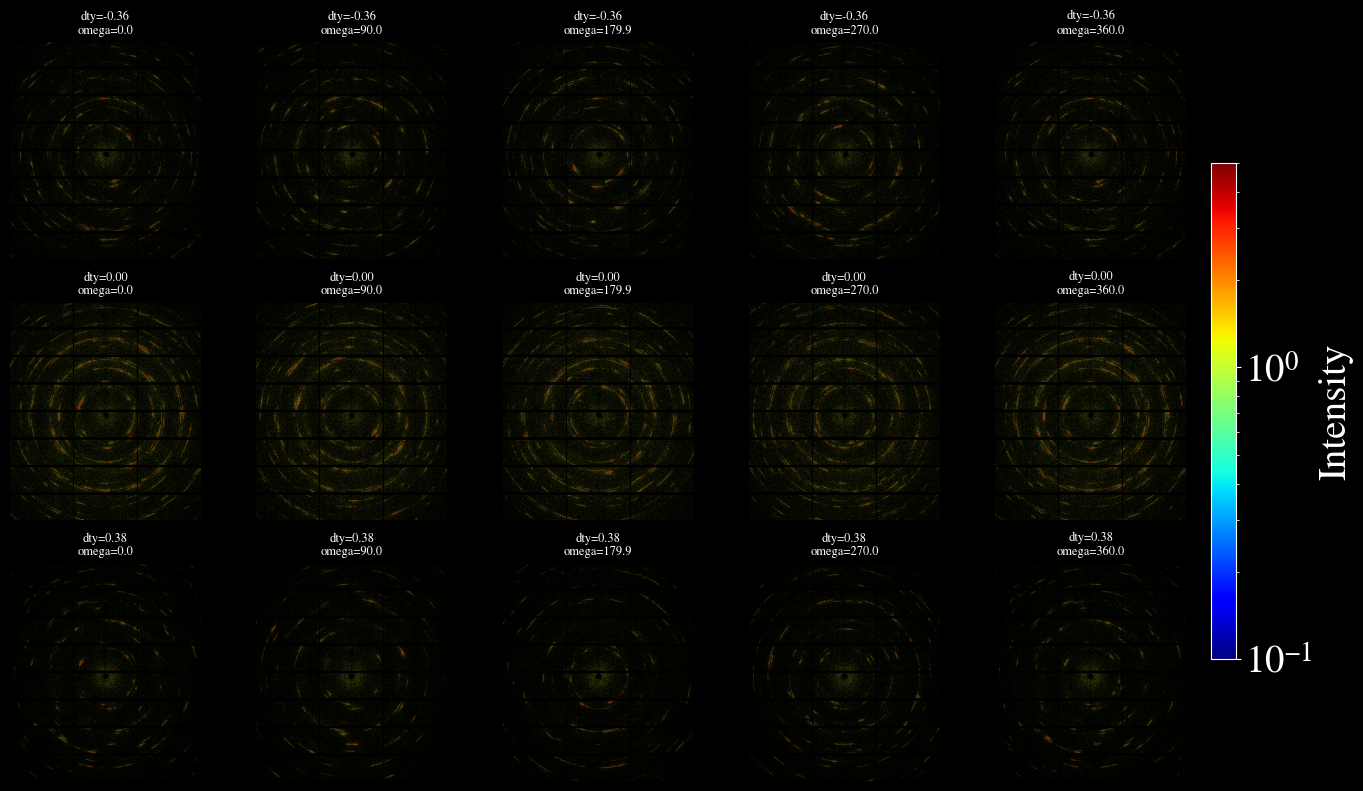

In [2]:
target_trans_frac = [0.25, 0.5, 0.75]
target_omega_deg = [0, 90, 180, 270, 360]  # deg

with DanMaxDataset() as ds:
    n_trans = ds.n_translations
    i_trans_list = [int(round(f * (n_trans - 1))) for f in target_trans_frac]

    fig, axes = plt.subplots(
        len(i_trans_list), len(target_omega_deg),
        figsize=(3.2 * len(target_omega_deg), 3.2 * len(i_trans_list)),
        squeeze=False,
    )

    im = None
    for row, i_trans in enumerate(i_trans_list):
        omega = ds.omega(i_trans)       # actual motor positions for this block
        dty_val = ds.translations()[i_trans]

        for col, target in enumerate(target_omega_deg):
            i_omega = int(np.argmin(np.abs(omega - target)))
            frame = ds.frame(i_trans, i_omega)

            print(
                f"i_trans={i_trans:3d} (dty={dty_val:8.4f})  "
                f"i_omega={i_omega:5d} (omega={omega[i_omega]:7.2f})"
            )

            ax = axes[row, col]
            im = ax.imshow(frame, vmin=0.1, vmax=5, norm="log", cmap="jet")
            ax.set_title(f"dty={dty_val:.2f}\nomega={omega[i_omega]:.1f}", fontsize=9)
            ax.axis("off")

    fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label="Intensity")
    plt.show()

## Predicted peaks
A fine 2D integration (q, azimuth) of the frames above, summed, with the powder peaks predicted from the
unit cell in the `.par` file (absences from the lattice centring removed).

21 distinct predicted peaks within the detector's q-range


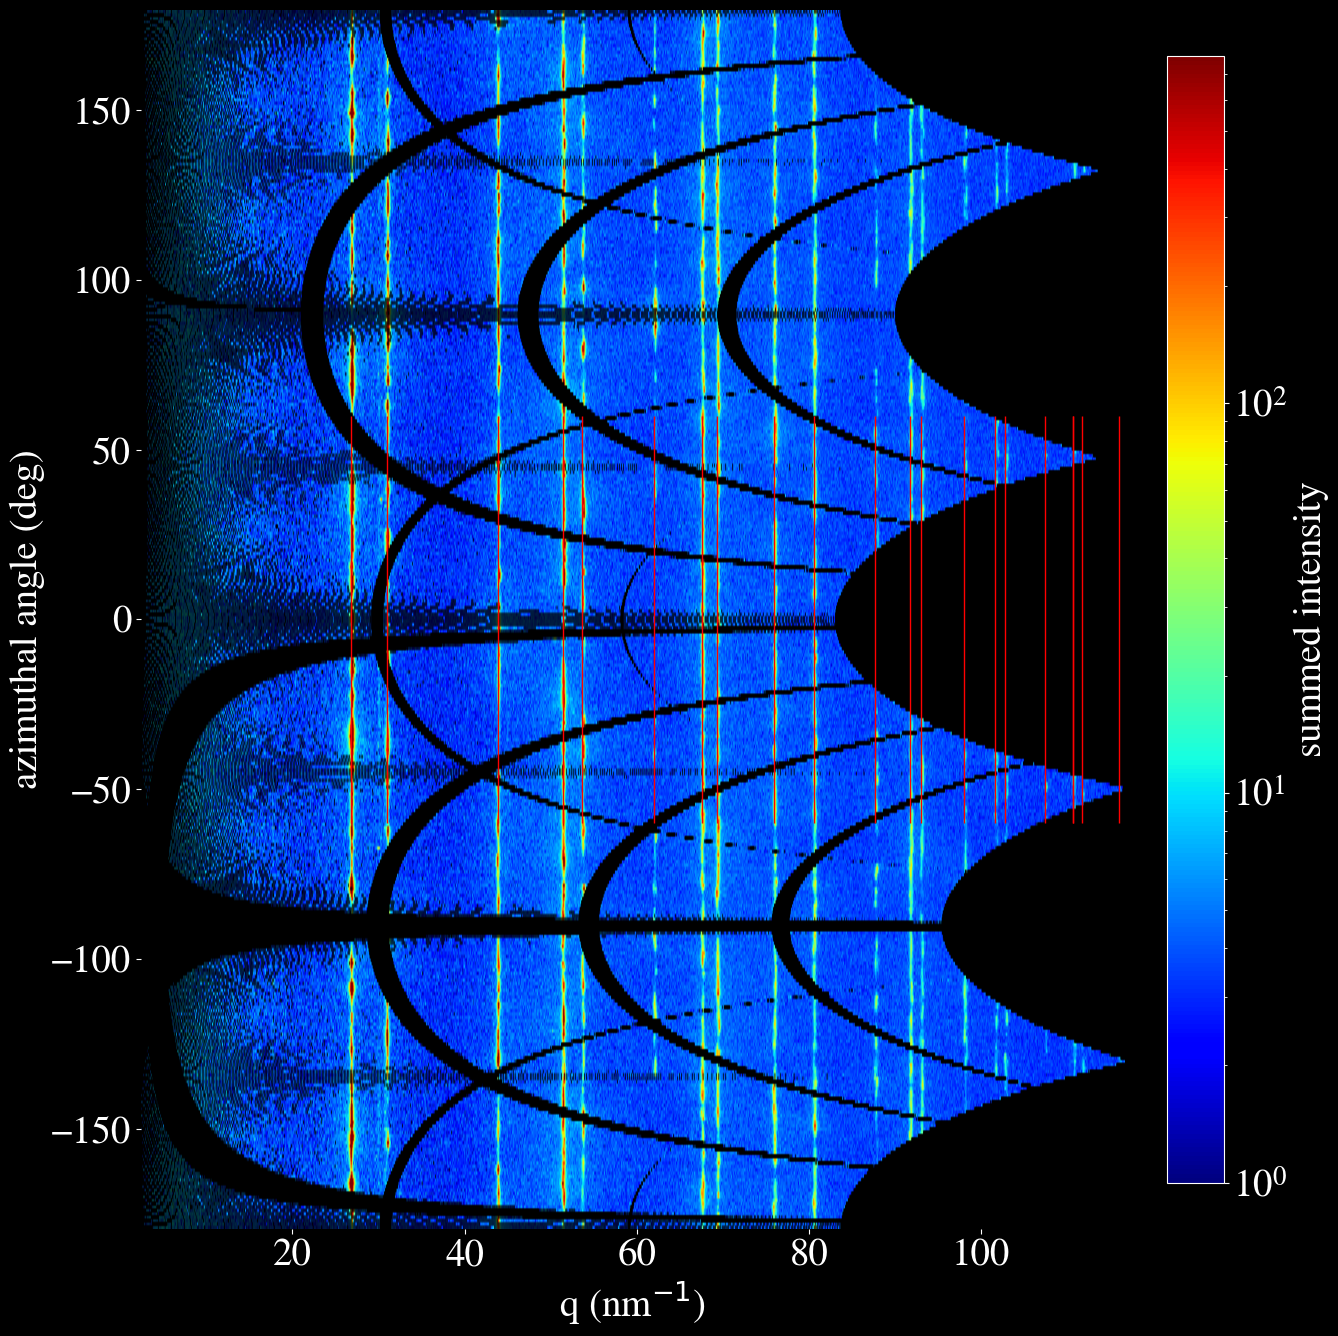

In [3]:
import pyFAI
import numpy as np
import matplotlib.pyplot as plt
from diffractom import Material
from integration.frame_loader import DanMaxDataset, PONI_PATH, PARAMETERS_AL1050, POLARIZATION_FACTOR

# --- integrate the frames over the full q-range and sum them ---
ai = pyFAI.load(PONI_PATH)

npt_rad = 2000
npt_azim = 360

target_trans_frac = [0.25, 0.5, 0.75]
target_omega_deg = [0, 90, 180, 270, 360]

I_sum, q, chi = None, None, None

with DanMaxDataset() as ds:
    mask = ds.mask()
    n_trans = ds.n_translations
    i_trans_list = [int(round(f * (n_trans - 1))) for f in target_trans_frac]

    for i_trans in i_trans_list:
        omega = ds.omega(i_trans)
        for target in target_omega_deg:
            i_omega = int(np.argmin(np.abs(omega - target)))
            frame = ds.frame(i_trans, i_omega)

            res = ai.integrate2d(
                frame,
                npt_rad=npt_rad,
                npt_azim=npt_azim,
                unit="q_nm^-1",
                mask=mask,
                method=("no", "csr", "opencl"),
                polarization_factor=POLARIZATION_FACTOR,
            )

            if I_sum is None:
                I_sum = np.zeros_like(res.intensity)
                q, chi = res.radial, res.azimuthal

            I_sum += res.intensity

I_sum = np.nan_to_num(I_sum)

# --- predict theoretical peak positions from the .par file ---
def read_par_file(path):
    params = {}
    with open(path) as f:
        for line in f:
            parts = line.split()
            if len(parts) >= 2:
                params[parts[0]] = parts[1]
    return params

par = read_par_file(PARAMETERS_AL1050)

q_min_A = q.min() / 10  # detector q-range: nm^-1 -> Å^-1
q_max_A = q.max() / 10
mat = Material.from_lattice_parameters(
    a=float(par["cell__a"]),
    b=float(par["cell__b"]),
    c=float(par["cell__c"]),
    alpha=float(par["cell_alpha"]),
    beta=float(par["cell_beta"]),
    gamma=float(par["cell_gamma"]),
    space_group_number=int(par["cell_lattice_[P,A,B,C,I,F,R]"]),
    wavelength_A=float(par["wavelength"]),
    q_min=q_min_A,
    q_max=q_max_A,
)

q_peaks_A = 2 * np.pi / mat.reflections["d_spacing"]
q_peaks_nm = q_peaks_A * 10  # back to nm^-1, matching the plot's q axis
q_peaks_nm = np.unique(q_peaks_nm)  # several hkl can share the same |q|

print(f"{len(q_peaks_nm)} distinct predicted peaks within the detector's q-range")

# --- plot with the predicted peak positions ---
vmin = max(I_sum[I_sum > 0].min(), 1)
vmax = np.percentile(I_sum, 99.9)

fig, ax = plt.subplots(1, 1, figsize=(14, 14))
im = ax.imshow(
    I_sum,
    extent=[q.min(), q.max(), chi.min(), chi.max()],
    origin="lower",
    aspect="auto",
    vmin=vmin, vmax=vmax, norm="log",
    cmap="jet",
)
ax.vlines(q_peaks_nm, ymin=-60, ymax=60, color="red", linewidth=1)
ax.set_xlabel(r"q (nm$^{-1}$)")
ax.set_ylabel("azimuthal angle (deg)")
fig.colorbar(im, ax=ax, fraction=0.052, pad=0.04, label="summed intensity")
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

## Choose the rings
All predicted peaks except the 7 at the highest q are used, each summed over a window of full width
`Q_WIDTH_NM` around its position.

14 peaks selected for integration, 7 highest-q peaks excluded


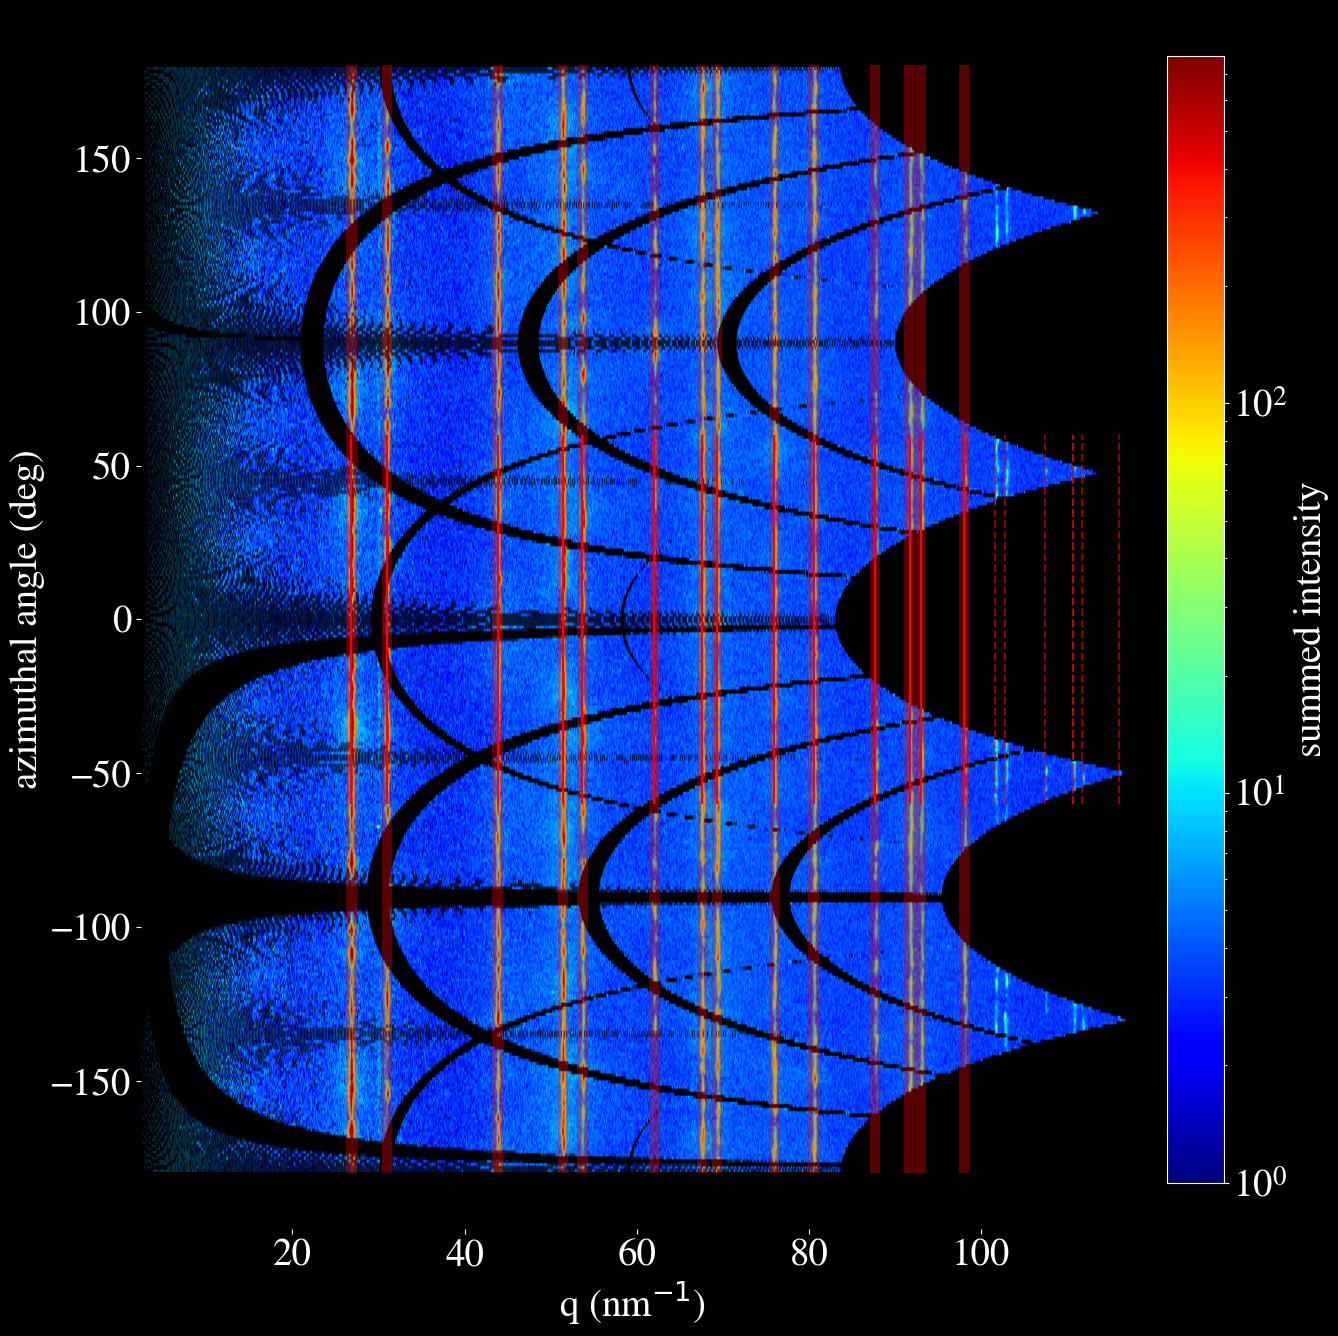

In [4]:
# --- q-width used for the integration bin around each selected peak ---
Q_WIDTH_NM = 1.2  # full width, in nm^-1 (same units as the q axis below)

# --- integrate the frames over the full q-range and sum them ---
ai = pyFAI.load(PONI_PATH)

npt_rad = 2000
npt_azim = 360

target_trans_frac = [0.25, 0.5, 0.75]
target_omega_deg = [0, 90, 180, 270, 360]

I_sum, q, chi = None, None, None

with DanMaxDataset() as ds:
    mask = ds.mask()
    n_trans = ds.n_translations
    i_trans_list = [int(round(f * (n_trans - 1))) for f in target_trans_frac]

    for i_trans in i_trans_list:
        omega = ds.omega(i_trans)
        for target in target_omega_deg:
            i_omega = int(np.argmin(np.abs(omega - target)))
            frame = ds.frame(i_trans, i_omega)

            res = ai.integrate2d(
                frame,
                npt_rad=npt_rad,
                npt_azim=npt_azim,
                unit="q_nm^-1",
                mask=mask,
                method=("no", "csr", "opencl"),
                polarization_factor=POLARIZATION_FACTOR,
            )

            if I_sum is None:
                I_sum = np.zeros_like(res.intensity)
                q, chi = res.radial, res.azimuthal

            I_sum += res.intensity

I_sum = np.nan_to_num(I_sum)

# --- predict theoretical peak positions from the .par file (extinctions applied) ---
def read_par_file(path):
    params = {}
    with open(path) as f:
        for line in f:
            parts = line.split()
            if len(parts) >= 2:
                params[parts[0]] = parts[1]
    return params

par = read_par_file(PARAMETERS_AL1050)

q_min_A = q.min() / 10  # detector q-range: nm^-1 -> Å^-1
q_max_A = q.max() / 10

mat = Material.from_lattice_parameters(
    a=float(par["cell__a"]),
    b=float(par["cell__b"]),
    c=float(par["cell__c"]),
    alpha=float(par["cell_alpha"]),
    beta=float(par["cell_beta"]),
    gamma=float(par["cell_gamma"]),
    space_group_number=int(par["cell_lattice_[P,A,B,C,I,F,R]"]),
    wavelength_A=float(par["wavelength"]),
    q_min=q_min_A,
    q_max=q_max_A,
)

q_peaks_A = 2 * np.pi / mat.reflections["d_spacing"]
q_peaks_nm = np.unique(q_peaks_A * 10)  # back to nm^-1, ascending, deduped

selected_peaks = q_peaks_nm[:-7]
excluded_peaks = q_peaks_nm[-7:]

print(f"{len(selected_peaks)} peaks selected for integration, "
      f"{len(excluded_peaks)} highest-q peaks excluded")

# --- plot: selected rings (shaded: integration window) and excluded peaks (dashed) ---
vmin = max(I_sum[I_sum > 0].min(), 1)
vmax = np.percentile(I_sum, 99.9)

fig, ax = plt.subplots(1, 1, figsize=(14, 14))
im = ax.imshow(
    I_sum,
    extent=[q.min(), q.max(), chi.min(), chi.max()],
    origin="lower",
    aspect="auto",
    vmin=vmin, vmax=vmax, norm="log",
    cmap="jet",
)

for peak in selected_peaks:
    ax.vlines(peak, ymin=-60, ymax=60, color="red", linewidth=1.5)


for peak in selected_peaks:
    ax.add_patch(Rectangle(
        (peak - Q_WIDTH_NM / 2, -180), Q_WIDTH_NM, 360,
        facecolor="red", alpha=0.35, edgecolor=None,
    ))

for peak in excluded_peaks:
    ax.vlines(peak, ymin=-60, ymax=60, color="red", linewidth=1.5,
               linestyle="--", alpha=0.55)

ax.set_xlabel(r"q (nm$^{-1}$)")
ax.set_ylabel("azimuthal angle (deg)")
fig.colorbar(im, ax=ax, fraction=0.052, pad=0.04, label="summed intensity")
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

## Check the ring binning
The full integration uses one coarse 2D integration over the q-range of all rings (`n_bins_per_ring`
radial bins per window) and sums the bins inside each window. Top: fine reference; bottom: the resulting
per-ring values drawn over the window of each ring.

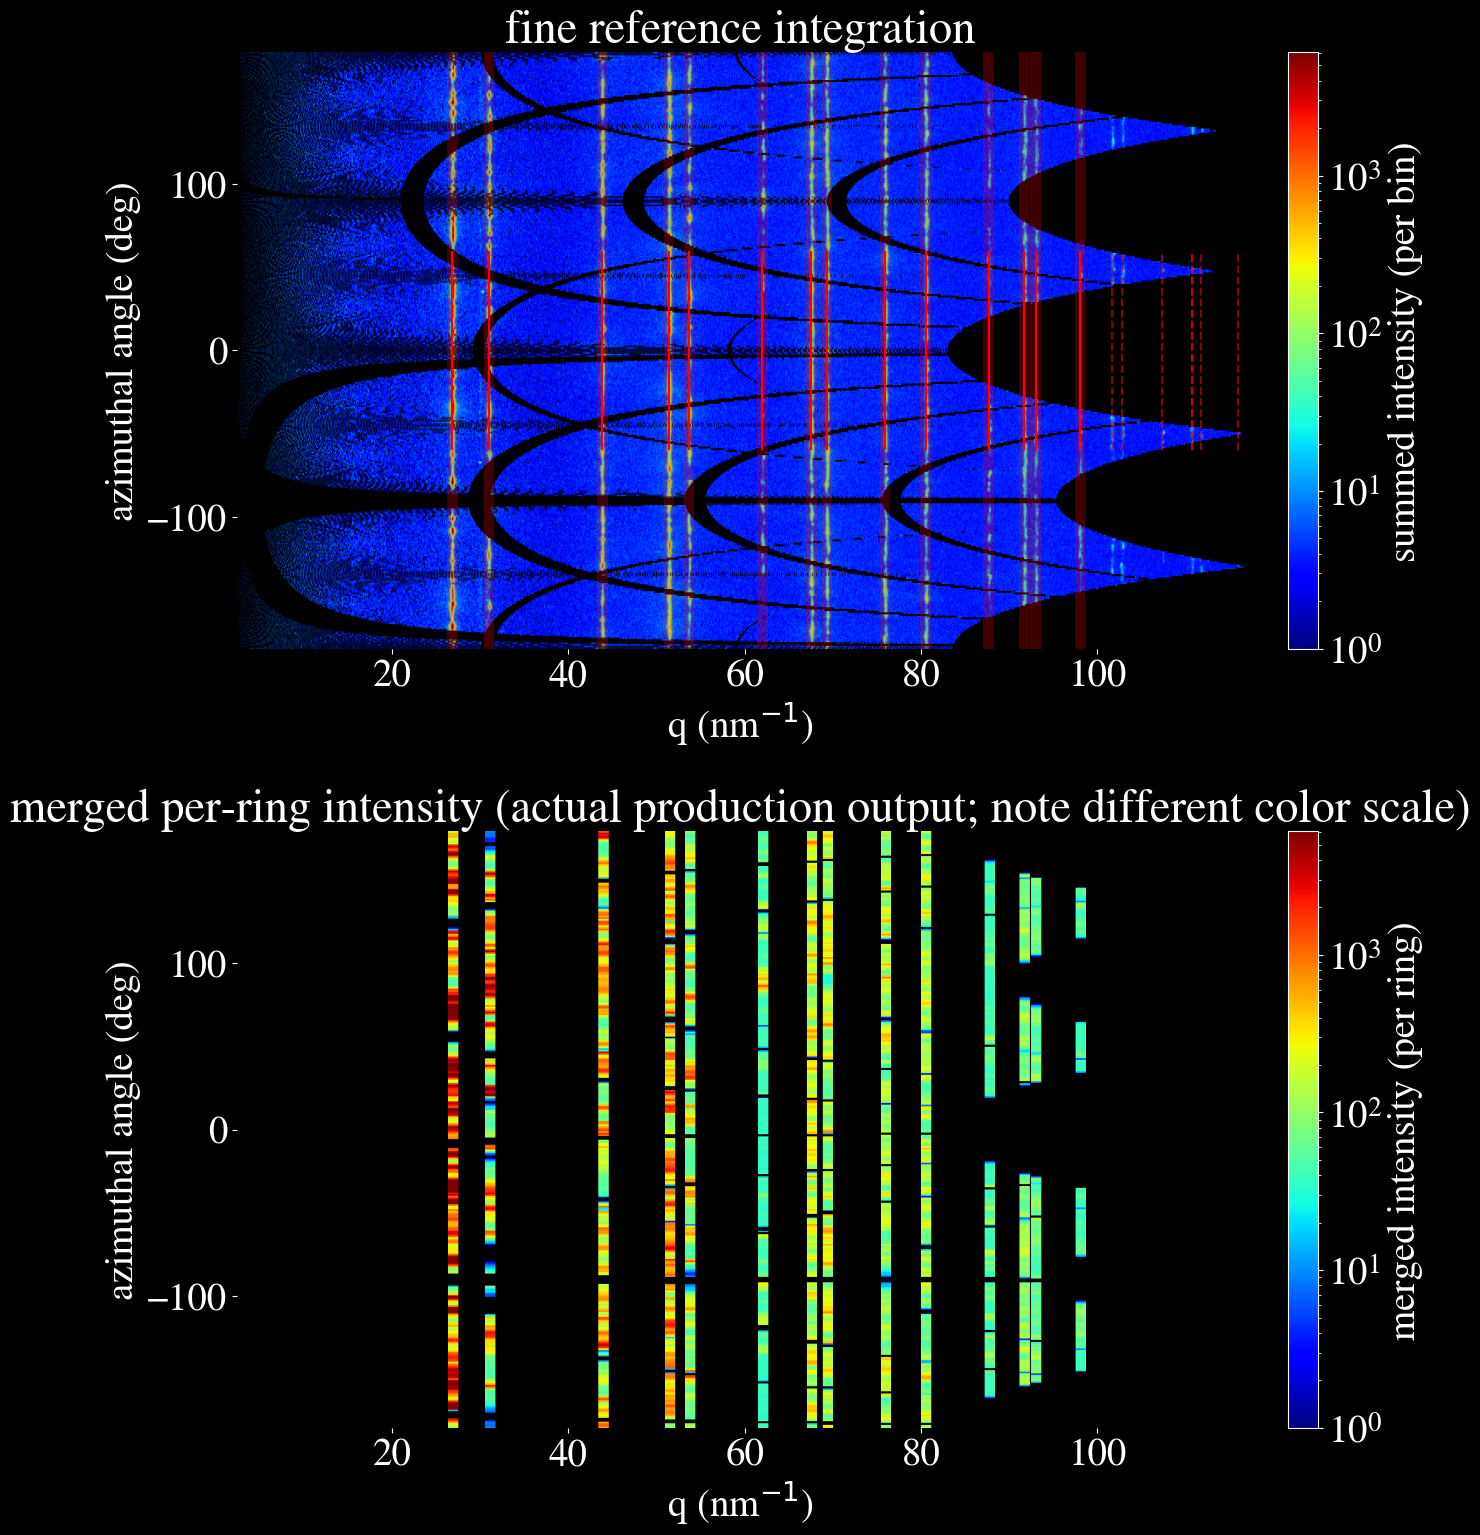

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

Q_WIDTH_NM = 1.2
npt_rad_fine = 2000
N_eta = 360

target_trans_frac = [0.25, 0.5, 0.75]
target_omega_deg = [0, 90, 180, 270, 360]

radial_ranges = [(p - Q_WIDTH_NM / 2, p + Q_WIDTH_NM / 2) for p in selected_peaks]
N_rings = len(radial_ranges)
q_range_min = min(lo for lo, hi in radial_ranges)
q_range_max = max(hi for lo, hi in radial_ranges)
n_bins_per_ring = 10  # only affects how precisely ring edges are resolved, not the final merged value
npt_rad_fast = int((q_range_max - q_range_min) / Q_WIDTH_NM * n_bins_per_ring)

I_sum, q, chi = None, None, None
I_fast_sum = None

with DanMaxDataset() as ds:
    mask = ds.mask()
    n_trans = ds.n_translations
    i_trans_list = [int(round(f * (n_trans - 1))) for f in target_trans_frac]

    for i_trans in i_trans_list:
        omega = ds.omega(i_trans)
        for target in target_omega_deg:
            i_omega = int(np.argmin(np.abs(omega - target)))
            frame = ds.frame(i_trans, i_omega)

            res = ai.integrate2d(
                frame, npt_rad=npt_rad_fine, npt_azim=N_eta,
                unit="q_nm^-1", mask=mask, method=("no", "csr", "opencl"),
                polarization_factor=POLARIZATION_FACTOR,
            )
            if I_sum is None:
                I_sum = np.zeros_like(res.intensity)
                q, chi = res.radial, res.azimuthal
            I_sum += res.intensity

            res_fast = ai.integrate2d(
                frame, npt_rad=npt_rad_fast, npt_azim=N_eta,
                radial_range=(q_range_min, q_range_max), unit="q_nm^-1",
                mask=mask, method=("no", "csr", "opencl"),
                polarization_factor=POLARIZATION_FACTOR,
            )
            if I_fast_sum is None:
                I_fast_sum = np.zeros_like(res_fast.intensity)
                fast_q = res_fast.radial
            I_fast_sum += res_fast.intensity

I_sum = np.nan_to_num(I_sum)
I_fast_sum = np.nan_to_num(I_fast_sum)

# per-ring, per-eta values, computed as in the full integration
ring_masks_fast = [(fast_q >= lo) & (fast_q < hi) for lo, hi in radial_ranges]
I_rings_merged = np.stack([I_fast_sum[:, sel].sum(axis=1) for sel in ring_masks_fast], axis=1)  # (N_eta, N_rings)


# build the merged-value image: each ring's q-window filled with one flat color
merged_image = np.full_like(fast_q, np.nan)[None, :].repeat(N_eta, axis=0)
for i_ring, sel in enumerate(ring_masks_fast):
    merged_image[:, sel] = I_rings_merged[:, i_ring:i_ring + 1]  # broadcast over q within the window

vmin_ref = max(I_sum[I_sum > 0].min(), 1)
vmax_ref = np.percentile(I_sum, 99.99)
vmin_merged = max(I_rings_merged[I_rings_merged > 0].min(), 1)
vmax_merged = np.percentile(I_rings_merged, 99.9)

fig, axes = plt.subplots(2, 1, figsize=(14, 16), height_ratios=[1, 1])

# --- panel 1: fine reference ---
ax = axes[0]
im = ax.imshow(
    I_sum, extent=[q.min(), q.max(), chi.min(), chi.max()],
    origin="lower", aspect="auto", vmin=vmin_ref, vmax=vmax_ref, norm="log", cmap="jet",
)
for peak in selected_peaks:
    ax.vlines(peak, ymin=-60, ymax=60, color="red", linewidth=1.5)
    ax.add_patch(Rectangle(
        (peak - Q_WIDTH_NM / 2, chi.min()), Q_WIDTH_NM, chi.max() - chi.min(),
        facecolor="red", alpha=0.25, edgecolor=None,
    ))
for peak in excluded_peaks:
    ax.vlines(peak, ymin=-60, ymax=60, color="red", linewidth=1.5,
               linestyle="--", alpha=0.55)
ax.set_xlabel(r"q (nm$^{-1}$)")
ax.set_ylabel("azimuthal angle (deg)")
ax.set_title("fine reference integration")
fig.colorbar(im, ax=ax, fraction=0.052, pad=0.04, label="summed intensity (per bin)")
for spine in ax.spines.values():
    spine.set_visible(False)

# --- panel 2: per-ring values on the same q axis ---
ax_mid = axes[1]
im_mid = ax_mid.imshow(
    merged_image, extent=[fast_q.min(), fast_q.max(), chi.min(), chi.max()],
    origin="lower", aspect="auto", vmin=vmin_ref, vmax=vmax_ref, norm="log", cmap="jet",
)
ax_mid.set_xlim(q.min(), q.max())
ax_mid.set_xlabel(r"q (nm$^{-1}$)")
ax_mid.set_ylabel("azimuthal angle (deg)")
ax_mid.set_title("per-ring intensity, as in the full integration")
fig.colorbar(im_mid, ax=ax_mid, fraction=0.052, pad=0.04, label="merged intensity (per ring)")
for spine in ax_mid.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

## Timing
One translation integrated frame by frame in a single process, to estimate the time for the whole
dataset.

In [6]:
import time
import numpy as np
import pyFAI

ai = pyFAI.load(PONI_PATH)

N_eta = 360
batch_size = 300  # frames read at a time

# selected_peaks, Q_WIDTH_NM from the previous notebook cell
radial_ranges = [(p - Q_WIDTH_NM / 2, p + Q_WIDTH_NM / 2) for p in selected_peaks]
N_rings = len(radial_ranges)

q_range_min = min(lo for lo, hi in radial_ranges)
q_range_max = max(hi for lo, hi in radial_ranges)

# n_bins_per_ring radial bins across every ring window
n_bins_per_ring = 10
npt_rad = int((q_range_max - q_range_min) / Q_WIDTH_NM * n_bins_per_ring)

with DanMaxDataset() as ds:
    mask = ds.mask()
    i_trans = ds.n_translations // 2
    n_omega = ds.n_omega(i_trans)

    def integrate_one(frame):
        return ai.integrate2d(
            frame,
            npt_rad=npt_rad,
            npt_azim=N_eta,
            radial_range=(q_range_min, q_range_max),
            unit="q_nm^-1",
            mask=mask,
            method=("no", "csr", "opencl"),
            polarization_factor=POLARIZATION_FACTOR,
        )

    # --- warm-up: builds/caches the CSR engine (paid once total) ---
    first_frame = ds.frame(i_trans, 0)
    t0 = time.perf_counter()
    res0 = integrate_one(first_frame)
    warmup_s = time.perf_counter() - t0
    print(f"warm-up (engine build): {warmup_s:.2f} s")

    # precompute, once, which output q-bins belong to which ring
    q_bins = res0.radial
    ring_masks = [(q_bins >= lo) & (q_bins < hi) for lo, hi in radial_ranges]

    def integrate_frame(frame):
        res = integrate_one(frame)  # one integrate2d call per frame covers all rings
        I = res.intensity  # (N_eta, npt_rad)
        out = np.empty((N_eta, N_rings), dtype=np.float32)
        for i_ring, sel in enumerate(ring_masks):
            out[:, i_ring] = I[:, sel].sum(axis=1)
        return out

    # --- steady-state ---
    I_out = np.empty((n_omega, N_eta, N_rings), dtype=np.float32)

    t0 = time.perf_counter()
    count = 0
    for start in range(0, n_omega, batch_size):
        count += 1
        stop = min(start + batch_size, n_omega)
        frames = ds.frames(i_trans, slice(start, stop))
        for i, frame in enumerate(frames):
            I_out[start + i] = integrate_frame(frame)
    steady_s = time.perf_counter() - t0

    per_frame_ms = 1000 * steady_s / n_omega
    print(f"steady-state: {steady_s:.1f} s for {n_omega} frames "
          f"({per_frame_ms:.2f} ms/frame)")

    total_frames = sum(ds.n_omega(i) for i in range(ds.n_translations))
    est_total_s = per_frame_ms / 1000 * total_frames
    print(f"estimated full-dataset time ({total_frames} frames): "
          f"{est_total_s / 60:.1f} min in a single process")

warm-up (engine build): 1.16 s
steady-state: 57.0 s for 3003 frames (18.99 ms/frame)
estimated full-dataset time (543543 frames): 172.0 min (without multiprocessing. May be faster!)


## Parameters
All settings are written to the `.json` before the integration starts: the rings, 360 azimuthal bins over
(-180, 180) deg, the radial range and bins, the integration method and the intensity corrections.
Polarization is corrected (`POLARIZATION_FACTOR`: the DanMAX beam is horizontally polarized); the
solid-angle correction is pyFAI's default; the Lorentz factor is not corrected, as the texture tomography
model accounts for it. A completed integration is never overwritten.

In [7]:
import inspect

N_eta = 360
ETA_RANGE_DEG = (-180.0, 180.0)   # explicit, degrees
N_BINS_PER_RING = 10              # radial bins per ring width; only sets how finely ring edges are resolved
INTEGRATION_METHOD = ("no", "csr", "opencl")
INTEGRATION_UNIT = "q_nm^-1"

eta_edges = np.linspace(ETA_RANGE_DEG[0], ETA_RANGE_DEG[1], N_eta + 1)
eta_centres = 0.5 * (eta_edges[:-1] + eta_edges[1:])

# radial settings, computed once here and read back by the integration cell from the json
radial_ranges = [(p - Q_WIDTH_NM / 2, p + Q_WIDTH_NM / 2) for p in selected_peaks]
q_range_min = float(min(lo for lo, hi in radial_ranges))
q_range_max = float(max(hi for lo, hi in radial_ranges))
npt_rad = int((q_range_max - q_range_min) / Q_WIDTH_NM * N_BINS_PER_RING)

# correction settings as the installed pyFAI actually applies them (read, not assumed)
integrate2d_args = inspect.signature(ai.integrate2d).parameters
assert "polarization_factor" in integrate2d_args, "this pyFAI's integrate2d has no polarization_factor argument"
solid_angle_applied = bool(integrate2d_args["correctSolidAngle"].default)  # not passed below, so the default applies
if "polarization_axis_offset" in integrate2d_args:
    pol_axis_offset_arg = integrate2d_args["polarization_axis_offset"].default
    pol_axis_offset_effective = pol_axis_offset_arg
else:
    pol_axis_offset_arg = None   # integrate2d has no such argument ...
    pol_axis_offset_effective = inspect.signature(ai.polarization).parameters["axis_offset"].default  # ... Geometry.polarization default is used

json_path = OUTPUT_PATH + ".json"
bin_path = OUTPUT_PATH + ".bin"

# never overwrite a finished run; an interrupted one (integration_complete=False) may be redone
if os.path.exists(json_path):
    with open(json_path) as f:
        if json.load(f).get("integration_complete", False):
            raise FileExistsError(
                f"{json_path} is a completed integration -- refusing to overwrite it. "
                "Change OUTPUT_FILENAME in frame_loader.py, or delete the old pair deliberately."
            )

with DanMaxDataset() as ds:
    translations = ds.translations()  # (N_y,) dty of every translation
    n_trans = ds.n_translations
    omega = ds.omega(0)               # rotation sequence, assumed identical across translations
    n_omega = len(omega)

    # check the assumption on two other translations (motor positions only)
    for i_trans in [n_trans // 2, n_trans - 1]:
        other = ds.omega(i_trans)
        if not np.allclose(other, omega, atol=1e-6):
            max_diff = np.abs(other - omega).max()
            print(f"WARNING: omega at translation {i_trans} differs from "
                  f"translation 0 by up to {max_diff:.4g} -- the 'shared "
                  f"omega' assumption may not hold, check before proceeding")

def reflections_for_q(mat, q_values_nm, tol=1e-8):
    """Match each merged-|q| ring back to every (h,k,l) family that landed on it."""
    q_all_A = 2 * np.pi / mat.reflections["d_spacing"]
    q_all_nm = q_all_A * 10
    out = []
    for qv in q_values_nm:
        matches = np.where(np.abs(q_all_nm - qv) < tol)[0]
        out.append({
            "q_nm": float(qv),
            "hkl": [mat.reflections["hkl"][i].tolist() for i in matches],
            "multiplicity": [int(mat.reflections["multiplicity"][i]) for i in matches],
            "d_spacing_A": float(mat.reflections["d_spacing"][matches[0]]),
            "two_theta_rad": float(mat.reflections["two_theta"][matches[0]]),
        })
    return out

selected_rings = reflections_for_q(mat, selected_peaks)

params = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "integration_complete": False,

    "geometry": {
        "poni_path": PONI_PATH,
        "parameters_path": PARAMETERS_AL1050,
        "mask_path": MASKFILE,
        "wavelength_A": ai.wavelength * 1e10,
    },

    "material": {
        "space_group_number": mat.space_group_number,
        "space_group_symbol": mat.space_group_symbol,
        "lattice_params": mat.lattice_params,
    },

    "rings": {
        "q_width_nm": Q_WIDTH_NM,
        "n_eta": N_eta,
        "eta_range_deg": list(ETA_RANGE_DEG),
        "eta_deg": eta_centres.tolist(),
        "selected": selected_rings,
    },

    "integration": {
        "n_bins_per_ring": N_BINS_PER_RING,
        "npt_rad": npt_rad,
        "method": list(INTEGRATION_METHOD),
        "unit": INTEGRATION_UNIT,
        "azimuth_range_deg": list(ETA_RANGE_DEG),
        "radial_range_nm": [q_range_min, q_range_max],
    },

    "corrections": {
        "polarization": {
            "applied": POLARIZATION_FACTOR is not None,
            "method": "pyFAI integrate2d polarization_factor",
            "factor": POLARIZATION_FACTOR,
            "axis_offset": pol_axis_offset_arg,
            "axis_offset_effective_rad": pol_axis_offset_effective,
            "convention": "pyFAI: +1 horizontal, -1 vertical, 0 circular",
            "pyfai_version": pyFAI.version,
        },
        "solid_angle": {"applied": solid_angle_applied, "note": "pyFAI default (correctSolidAngle), unchanged"},
        "lorentz": {"applied": False, "note": "intentionally not corrected; handled by the downstream fitting model"},
    },

    "scan": {
        "n_translations": n_trans,
        "n_omega": n_omega,
        "translations_dty": translations.tolist(),
        "omega_deg": omega.tolist(),  # single shared sequence, not per-translation
    },

    "output": {
        "bin_path": bin_path,
        "dtype": "float32",
        "shape": [n_trans, n_omega, N_eta, len(selected_peaks)],
        "shape_axes": ["translation", "omega", "eta", "q_ring"],
        "memmap_order": "C",
    },
}

os.makedirs(os.path.dirname(json_path), exist_ok=True)
with open(json_path, "w") as f:
    json.dump(params, f, indent=2)

n_bytes = 4 * np.prod(params["output"]["shape"])
print(f"Output array shape: {params['output']['shape']}")
print(f"Expected .bin size: {n_bytes / 1e9:.2f} GB")
print(f"Corrections: {json.dumps(params['corrections'], indent=1)}")
print(f"Integration: {json.dumps(params['integration'])}")
print(f"Wrote parameters to {json_path}")

Output array shape: [181, 3003, 360, 14]
Expected .bin size: 10.96 GB
Corrections: {
 "polarization": {
  "applied": true,
  "method": "pyFAI integrate2d polarization_factor",
  "factor": 1.0,
  "axis_offset": null,
  "axis_offset_effective_rad": 0,
  "convention": "pyFAI: +1 horizontal, -1 vertical, 0 circular",
  "pyfai_version": "2026.1.0-dev0"
 },
 "solid_angle": {
  "applied": true,
  "note": "pyFAI default (correctSolidAngle), unchanged"
 },
 "lorentz": {
  "applied": false,
  "note": "intentionally not corrected; handled by the downstream fitting model"
 }
}
Integration: {"n_bins_per_ring": 10, "npt_rad": 603, "method": ["no", "csr", "opencl"], "unit": "q_nm^-1", "azimuth_range_deg": [-180.0, 180.0], "radial_range_nm": [26.244588518513336, 98.62257785689293]}
Wrote parameters to /dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/scan-0048-0058_integrated_polcorr.json


## Integrate
Worker processes decompress batches of frames into shared memory and the main process integrates them on
the GPU: one `integrate2d` call per frame covers all rings, and the ring windows are summed with a 0/1
matrix. Every setting is read back from the `.json`, so the record matches what was run; the `.json` is
marked complete only at the end.

In [8]:
import time
import json
import numpy as np
import pyFAI
from multiprocessing import shared_memory
from concurrent.futures import ProcessPoolExecutor, wait, FIRST_COMPLETED
import h5py
from integration.frame_loader import DanMaxDataset, read_batch_into_shm, FRAMES

with open(json_path) as f:
    params = json.load(f)

ai = pyFAI.load(params["geometry"]["poni_path"])

# every integration setting comes from the json, so what is recorded is exactly what runs
Q_WIDTH_NM = params["rings"]["q_width_nm"]
N_eta = params["rings"]["n_eta"]
selected_q = np.array([r["q_nm"] for r in params["rings"]["selected"]])
radial_ranges = [(q0 - Q_WIDTH_NM / 2, q0 + Q_WIDTH_NM / 2) for q0 in selected_q]
N_rings = len(radial_ranges)

integ = params["integration"]
eta_range = tuple(integ["azimuth_range_deg"])
q_range_min, q_range_max = integ["radial_range_nm"]
npt_rad = integ["npt_rad"]
method = tuple(integ["method"])
unit = integ["unit"]
pol_factor = params["corrections"]["polarization"]["factor"]
assert eta_range == tuple(params["rings"]["eta_range_deg"])
print(f"integrating with polarization_factor={pol_factor}, npt_rad={npt_rad}, method={method}")

shape = tuple(params["output"]["shape"])
I_out = np.memmap(params["output"]["bin_path"], dtype=params["output"]["dtype"],
                   mode="w+", shape=shape)

read_batch_size = 10
n_worker_processes = 16
n_shm_buffers = n_worker_processes + 2

with DanMaxDataset() as ds:
    mask = ds.mask()
    n_trans = ds.n_translations
    assert n_trans == shape[0]

    probe_path, probe_start, _ = ds.raw_location(0)
    with h5py.File(probe_path, "r") as f:
        frame_shape = f[FRAMES].shape[1:]
        dtype_str = str(f[FRAMES].dtype)

    buf_nbytes = read_batch_size * np.prod(frame_shape) * np.dtype(dtype_str).itemsize
    print(f"shared-memory pool: {n_shm_buffers} buffers x {buf_nbytes/1e6:.0f} MB "
          f"= {n_shm_buffers * buf_nbytes / 1e9:.2f} GB total "
          "(must fit in /dev/shm)")

    probe = ds.frame(0, 0)
    res0 = ai.integrate2d(
        probe, npt_rad=npt_rad, npt_azim=N_eta,
        radial_range=(q_range_min, q_range_max),
        azimuth_range=eta_range,
        unit=unit, mask=mask, method=method,
        polarization_factor=pol_factor,
    )

    # pyFAI's azimuthal bin centres must match eta_deg in the json. They differ from the idealised
    # np.linspace centres by up to ~2e-5 deg (floating point), far below the 1 deg bin width.
    assert np.allclose(res0.azimuthal, params["rings"]["eta_deg"], atol=1e-3), (
        "pyFAI's azimuthal bin centres don't match eta_deg in the json"
    )
    ring_masks = [(res0.radial >= lo) & (res0.radial < hi) for lo, hi in radial_ranges]

    # 0/1 matrix (npt_rad, N_rings) that sums the radial bins inside each ring window
    ring_matrix = np.zeros((npt_rad, N_rings), dtype=np.float32)
    for i_ring, sel in enumerate(ring_masks):
        ring_matrix[sel, i_ring] = 1.0

    shm_blocks = [shared_memory.SharedMemory(create=True, size=int(buf_nbytes))
                  for _ in range(n_shm_buffers)]
    shm_arrays = {
        shm.name: np.ndarray((read_batch_size,) + frame_shape, dtype=dtype_str, buffer=shm.buf)
        for shm in shm_blocks
    }

    def integrate_translation(pool, path, abs_start, abs_stop, out_view, free_names):
        n_omega = abs_stop - abs_start
        starts = list(range(abs_start, abs_stop, read_batch_size))
        pending = {}
        next_idx = 0

        def submit_next():
            nonlocal next_idx
            if next_idx >= len(starts) or not free_names:
                return
            name = free_names.pop()
            s = starts[next_idx]
            stop = min(s + read_batch_size, abs_stop)
            fut = pool.submit(read_batch_into_shm, path, s, stop, name,
                               read_batch_size, frame_shape, dtype_str)
            pending[fut] = (s, stop, name)
            next_idx += 1

        while free_names and next_idx < len(starts):
            submit_next()

        while pending:
            done, _ = wait(pending.keys(), return_when=FIRST_COMPLETED)
            for fut in done:
                s, stop, name = pending.pop(fut)
                n = fut.result()
                buf = shm_arrays[name]
                local_start = s - abs_start

                # integrate the batch, then write it to the memmap in one go
                batch_out = np.empty((n, N_eta, N_rings), dtype=np.float32)
                for i in range(n):
                    res = ai.integrate2d(
                        buf[i], npt_rad=npt_rad, npt_azim=N_eta,
                        radial_range=(q_range_min, q_range_max),
                        azimuth_range=eta_range,
                        unit=unit, mask=mask, method=method,
                        polarization_factor=pol_factor,
                    )
                    # (N_eta, npt_rad) @ (npt_rad, N_rings) -> (N_eta, N_rings)
                    batch_out[i] = res.intensity @ ring_matrix

                out_view[local_start:local_start + n] = batch_out

                free_names.append(name)
                submit_next()

    try:
        with ProcessPoolExecutor(max_workers=n_worker_processes) as pool:
            free_names = [shm.name for shm in shm_blocks]

            t0 = time.perf_counter()
            n_frames_done = 0

            for i_trans in range(n_trans):
                n_omega = ds.n_omega(i_trans)
                assert n_omega == shape[1]

                path, abs_start, abs_stop = ds.raw_location(i_trans)
                integrate_translation(pool, path, abs_start, abs_stop, I_out[i_trans], free_names)
                n_frames_done += n_omega

                elapsed = time.perf_counter() - t0
                rate = n_frames_done / elapsed
                remaining_s = (shape[0] * shape[1] - n_frames_done) / rate
                print(f"translation {i_trans + 1}/{n_trans}  "
                      f"({rate:.1f} fr/s, ~{remaining_s / 60:.1f} min remaining)")
    finally:
        for shm in shm_blocks:
            shm.close()
            shm.unlink()

I_out.flush()
del I_out

params["integration_complete"] = True
with open(json_path, "w") as f:
    json.dump(params, f, indent=2)

print("Integration complete.")

integrating with polarization_factor=1.0, npt_rad=603, method=('no', 'csr', 'opencl')
shared-memory pool: 18 buffers x 99 MB = 1.78 GB total -- check this fits under /dev/shm's size limit on your cluster node
translation 1/181  (126.0 fr/s, ~71.5 min remaining)
translation 2/181  (128.3 fr/s, ~69.8 min remaining)
translation 3/181  (128.8 fr/s, ~69.2 min remaining)
translation 4/181  (129.3 fr/s, ~68.5 min remaining)
translation 5/181  (129.6 fr/s, ~68.0 min remaining)
translation 6/181  (129.8 fr/s, ~67.5 min remaining)
translation 7/181  (129.7 fr/s, ~67.1 min remaining)
translation 8/181  (129.8 fr/s, ~66.7 min remaining)
translation 9/181  (129.8 fr/s, ~66.3 min remaining)
translation 10/181  (130.0 fr/s, ~65.9 min remaining)
translation 11/181  (130.0 fr/s, ~65.5 min remaining)
translation 12/181  (130.0 fr/s, ~65.1 min remaining)
translation 13/181  (130.0 fr/s, ~64.7 min remaining)
translation 14/181  (130.1 fr/s, ~64.3 min remaining)
translation 15/181  (130.0 fr/s, ~63.9 min r

The full integration takes about one hour on one GPU. Reading is not the bottleneck: the frames are
decompressed on the CPU by the worker processes. The result is loaded with `IntegratedData`:

In [9]:
# The integrated file can be loaded with:
from integration.integrated_data import IntegratedData

data = IntegratedData(OUTPUT_PATH)  # no suffix
assert data.polarization_corrected is True, (
    f"{data.json_path} is not polarization corrected (polarization_corrected={data.polarization_corrected}); "
    "reintegrate with the polarization correction before any ring normalisation."
)
print(data)


IntegratedData: /dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/scan-0048-0058_integrated_polcorr.json
  array   : (181, 3003, 360, 14)  axes=['translation', 'omega', 'eta', 'q_ring']  float32  (10.96 GB, memmap)
  dty     : 181 steps, -0.75 .. 0.75
  omega   : 3003 steps, 0 .. 360.1 deg
  eta     : 360 bins, range -180..180 deg
  rings   : 14, q_width = 1.2 nm^-1
    [ 0] q =   26.845 nm^-1   hkl: (-1, -1, -1)
    [ 1] q =   30.997 nm^-1   hkl: (-2, 0, 0)
    [ 2] q =   43.837 nm^-1   hkl: (-2, -2, 0)
    [ 3] q =   51.403 nm^-1   hkl: (-3, -1, -1)
    [ 4] q =   53.689 nm^-1   hkl: (-2, -2, -2)
    [ 5] q =   61.995 nm^-1   hkl: (-4, 0, 0)
    [ 6] q =   67.557 nm^-1   hkl: (-3, -3, -1)
    [ 7] q =   69.312 nm^-1   hkl: (-4, -2, 0)
    [ 8] q =   75.928 nm^-1   hkl: (-4, -2, -2)
    [ 9] q =   80.534 nm^-1   hkl: (-3, -3, -3), (-5, -1, -1)
    [10] q =   87.674 nm^-1   hkl: (-4, -4, 0)
    [11] q =   91.692 nm^-1   hkl: (-5, -3, -1)
  